In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# If the notebook is run from the notebooks folder, move to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')


## 1. Load Raw UNSW-NB15 Data

In [3]:
TRAIN_PATH = '/content/UNSW_NB15_training-set.xlsx'
TEST_PATH = '/content/UNSW_NB15_testing-set.xlsx'

train_df = pd.read_excel(TRAIN_PATH)
test_df = pd.read_excel(TEST_PATH)

train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print(f'Training shape: {train_df.shape}')
print(f'Testing shape: {test_df.shape}')

print(f'\nColumns ({len(train_df.columns)}):')
print(list(train_df.columns))

print('\nTraining label distribution:')
print(train_df['label'].value_counts())

print('\nAttack categories:')
print(train_df['attack_cat'].value_counts())

print(f'\nData types:\n{train_df.dtypes.value_counts()}')
print(f'\nMissing values in training:\n{train_df.isna().sum().sort_values(ascending=False).head(20)}')


Training shape: (175341, 45)
Testing shape: (82332, 45)

Columns (45):
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Training label distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Attack categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Data types:
int64      30
fl

## 2. Data Cleaning

In [4]:
# Drop rows that are entirely NaN
train_df = train_df.dropna(how='all').reset_index(drop=True)
test_df = test_df.dropna(how='all').reset_index(drop=True)

# Drop duplicate rows
train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

print(f'Training shape after cleaning: {train_df.shape}')
print(f'Testing shape after cleaning: {test_df.shape}')

print(f'\nTraining missing values: {int(train_df.isna().sum().sum())}')
print(f'Testing missing values: {int(test_df.isna().sum().sum())}')


Training shape after cleaning: (175341, 45)
Testing shape after cleaning: (82332, 45)

Training missing values: 0
Testing missing values: 0


In [5]:
# ID is an identifier, not a useful predictive feature.
# Keep attack_cat and label because they are targets/labels.
DROP_COLS = ['id']

train_df = train_df.drop(columns=DROP_COLS, errors='ignore')
test_df = test_df.drop(columns=DROP_COLS, errors='ignore')

print(f'Training shape after dropping ID: {train_df.shape}')
print(f'Remaining columns: {list(train_df.columns)}')


Training shape after dropping ID: (175341, 44)
Remaining columns: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [6]:
LABEL_COL = 'label'
ATTACK_CAT_COL = 'attack_cat'

# Standardize categorical text
for data in [train_df, test_df]:
    for col in ['proto', 'service', 'state', 'attack_cat']:
        if col in data.columns:
            data[col] = data[col].astype(str).str.strip()

# Numeric feature columns
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_feature_cols = [c for c in numeric_cols if c != LABEL_COL]

# Replace inf/-inf with NaN
train_df[numeric_feature_cols] = train_df[numeric_feature_cols].replace([np.inf, -np.inf], np.nan)
test_df[numeric_feature_cols] = test_df[numeric_feature_cols].replace([np.inf, -np.inf], np.nan)

print(f'Numeric feature count: {len(numeric_feature_cols)}')
print(f'NaNs after numeric cleaning - train: {int(train_df[numeric_feature_cols].isna().sum().sum())}')
print(f'NaNs after numeric cleaning - test: {int(test_df[numeric_feature_cols].isna().sum().sum())}')


Numeric feature count: 39
NaNs after numeric cleaning - train: 0
NaNs after numeric cleaning - test: 0


In [7]:
# Median imputation using TRAINING statistics only
train_medians = train_df[numeric_feature_cols].median()

train_df[numeric_feature_cols] = train_df[numeric_feature_cols].fillna(train_medians)
test_df[numeric_feature_cols] = test_df[numeric_feature_cols].fillna(train_medians)

print(f'NaNs after median imputation - train: {int(train_df[numeric_feature_cols].isna().sum().sum())}')
print(f'NaNs after median imputation - test: {int(test_df[numeric_feature_cols].isna().sum().sum())}')


NaNs after median imputation - train: 0
NaNs after median imputation - test: 0


## 3. Label Encoding

In [8]:
# UNSW-NB15 already provides a binary label:
# 0 = Normal
# 1 = Attack

train_df['Label_binary'] = np.where(train_df[LABEL_COL].astype(int) == 1, 'ATTACK', 'BENIGN')
test_df['Label_binary'] = np.where(test_df[LABEL_COL].astype(int) == 1, 'ATTACK', 'BENIGN')

train_df['Label_encoded'] = train_df[LABEL_COL].astype(int)
test_df['Label_encoded'] = test_df[LABEL_COL].astype(int)

# Multiclass target based on attack_cat
# Normalize the category names and keep Normal as BENIGN where applicable.
for data in [train_df, test_df]:
    data['attack_cat_clean'] = data[ATTACK_CAT_COL].replace({
        'Normal': 'BENIGN',
        'normal': 'BENIGN',
        'Normal ': 'BENIGN'
    })

le = LabelEncoder()
all_attack_categories = pd.concat(
    [train_df['attack_cat_clean'], test_df['attack_cat_clean']],
    ignore_index=True
).astype(str)

le.fit(all_attack_categories)
train_df['Label_multiclass'] = le.transform(train_df['attack_cat_clean'].astype(str))
test_df['Label_multiclass'] = le.transform(test_df['attack_cat_clean'].astype(str))

print('Binary label distribution - training:')
print(train_df['Label_binary'].value_counts())

print('\nMulticlass label distribution - training:')
print(train_df['attack_cat_clean'].value_counts())

print(f'\nEncoded multiclass classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')


Binary label distribution - training:
Label_binary
ATTACK    119341
BENIGN     56000
Name: count, dtype: int64

Multiclass label distribution - training:
attack_cat_clean
BENIGN            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Encoded multiclass classes: {'Analysis': np.int64(0), 'BENIGN': np.int64(1), 'Backdoor': np.int64(2), 'DoS': np.int64(3), 'Exploits': np.int64(4), 'Fuzzers': np.int64(5), 'Generic': np.int64(6), 'Reconnaissance': np.int64(7), 'Shellcode': np.int64(8), 'Worms': np.int64(9)}


## 4. Feature Engineering

In [9]:
def add_unsw_features(data):
    data = data.copy()

    # Packet and byte totals
    data['total_packets'] = data['spkts'] + data['dpkts']
    data['total_bytes'] = data['sbytes'] + data['dbytes']

    # Forward/backward ratios
    data['fwd_to_bwd_pkt_ratio'] = data['spkts'] / (data['dpkts'] + 1)
    data['fwd_to_bwd_byte_ratio'] = data['sbytes'] / (data['dbytes'] + 1)

    # Loss ratios
    data['fwd_loss_ratio'] = data['sloss'] / (data['spkts'] + 1)
    data['bwd_loss_ratio'] = data['dloss'] / (data['dpkts'] + 1)

    # Load ratios
    data['fwd_to_bwd_load_ratio'] = data['sload'] / (data['dload'] + 1)

    # Inter-arrival time ratios
    data['fwd_to_bwd_iat_ratio'] = data['sinpkt'] / (data['dinpkt'] + 1)
    data['fwd_jitter_to_bwd_jitter_ratio'] = data['sjit'] / (data['djit'] + 1)

    # TCP timing ratios
    data['synack_to_tcprtt_ratio'] = data['synack'] / (data['tcprtt'] + 1)
    data['ackdat_to_tcprtt_ratio'] = data['ackdat'] / (data['tcprtt'] + 1)

    # Mean packet size relationship
    data['smean_to_dmean_ratio'] = data['smean'] / (data['dmean'] + 1)

    # Connection/traffic density features
    data['bytes_per_packet'] = data['total_bytes'] / (data['total_packets'] + 1)
    data['packets_per_second'] = data['total_packets'] / (data['dur'] + 1e-6)

    # Log transforms for highly skewed quantities
    data['duration_log'] = np.log1p(data['dur'].clip(lower=0))
    data['sbytes_log'] = np.log1p(data['sbytes'].clip(lower=0))
    data['dbytes_log'] = np.log1p(data['dbytes'].clip(lower=0))
    data['rate_log'] = np.log1p(data['rate'].clip(lower=0))

    # Binary indicators
    data['has_ftp_login'] = (data['is_ftp_login'].fillna(0) > 0).astype(int)
    data['has_http_method'] = (data['ct_flw_http_mthd'].fillna(0) > 0).astype(int)
    data['is_sm_ips'] = (data['is_sm_ips_ports'].fillna(0) > 0).astype(int)

    return data

train_df = add_unsw_features(train_df)
test_df = add_unsw_features(test_df)

label_cols = [
    LABEL_COL, ATTACK_CAT_COL, 'attack_cat_clean',
    'Label_binary', 'Label_encoded', 'Label_multiclass'
]

feature_cols_before_encoding = [
    c for c in train_df.columns if c not in label_cols
]

print(f'Total features after engineering: {len(feature_cols_before_encoding)}')
print('New engineered features:')
print([c for c in feature_cols_before_encoding if c not in numeric_cols and c not in ['proto','service','state']])


Total features after engineering: 63
New engineered features:
['total_packets', 'total_bytes', 'fwd_to_bwd_pkt_ratio', 'fwd_to_bwd_byte_ratio', 'fwd_loss_ratio', 'bwd_loss_ratio', 'fwd_to_bwd_load_ratio', 'fwd_to_bwd_iat_ratio', 'fwd_jitter_to_bwd_jitter_ratio', 'synack_to_tcprtt_ratio', 'ackdat_to_tcprtt_ratio', 'smean_to_dmean_ratio', 'bytes_per_packet', 'packets_per_second', 'duration_log', 'sbytes_log', 'dbytes_log', 'rate_log', 'has_ftp_login', 'has_http_method', 'is_sm_ips']


## 5. Encode Categorical Features

In [10]:
# Use only input features; attack_cat is a label, not an input feature.
categorical_cols = ['proto', 'service', 'state']

X_train = train_df.drop(columns=label_cols, errors='ignore').copy()
X_test = test_df.drop(columns=label_cols, errors='ignore').copy()

# One-hot encode categorical columns.
X_train = pd.get_dummies(X_train, columns=categorical_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=categorical_cols, dtype=int)

# Make test columns exactly match train columns.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Clean remaining numeric issues.
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

y_train = train_df['Label_encoded'].copy()
y_test = test_df['Label_encoded'].copy()

print(f'Encoded X_train shape: {X_train.shape}')
print(f'Encoded X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')
print('\nTarget distribution:')
print(y_train.value_counts())


Encoded X_train shape: (175341, 215)
Encoded X_test shape: (82332, 215)
y_train shape: (175341,)
y_test shape: (82332,)

Target distribution:
Label_encoded
1    119341
0     56000
Name: count, dtype: int64


## 6. Scale Features

In [11]:
# Fit scaler only on training data to avoid test-data leakage.
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f'Scaled X_train shape: {X_train_scaled.shape}')
print(f'Scaled X_test shape: {X_test_scaled.shape}')


Scaled X_train shape: (175341, 215)
Scaled X_test shape: (82332, 215)


## 7. Visualizations

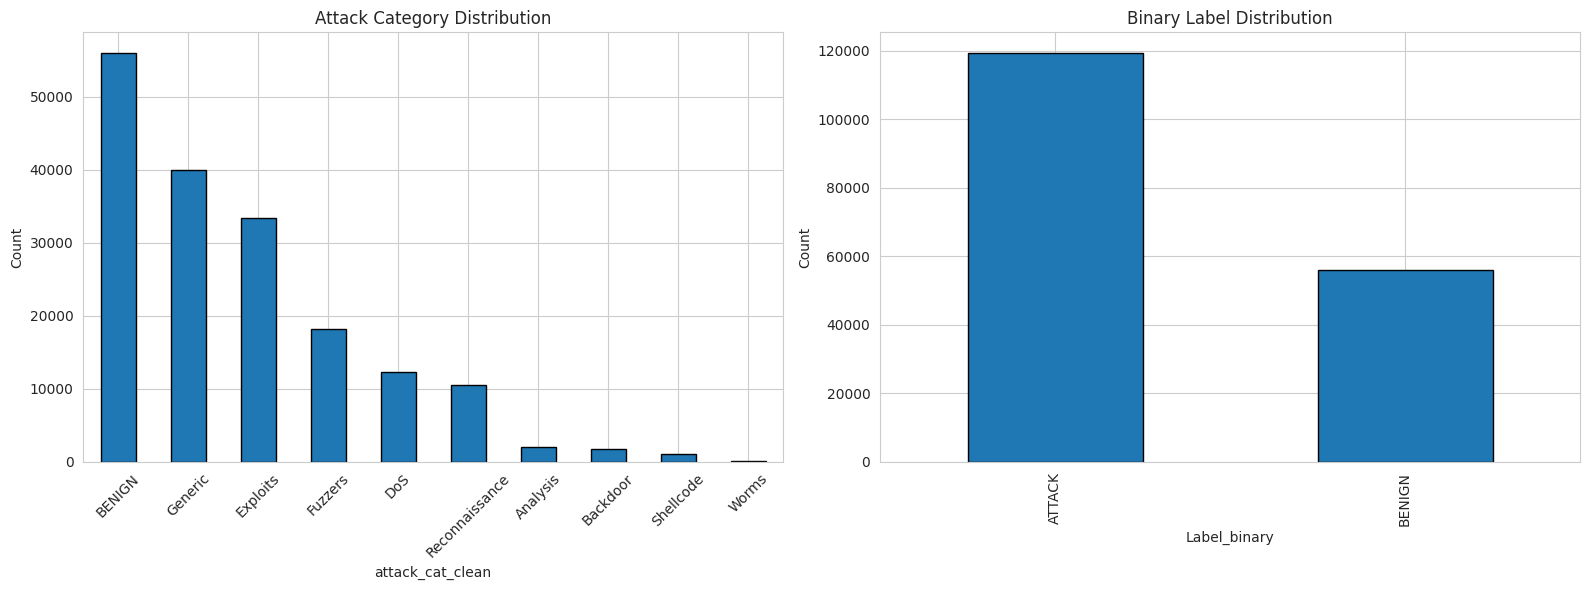

Saved: results/label_distribution_unsw.png


In [12]:
os.makedirs('results', exist_ok=True)

# Binary label distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_df['attack_cat_clean'].value_counts().plot(
    kind='bar', ax=axes[0], edgecolor='black'
)
axes[0].set_title('Attack Category Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

train_df['Label_binary'].value_counts().plot(
    kind='bar', ax=axes[1], edgecolor='black'
)
axes[1].set_title('Binary Label Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('results/label_distribution_unsw.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: results/label_distribution_unsw.png')


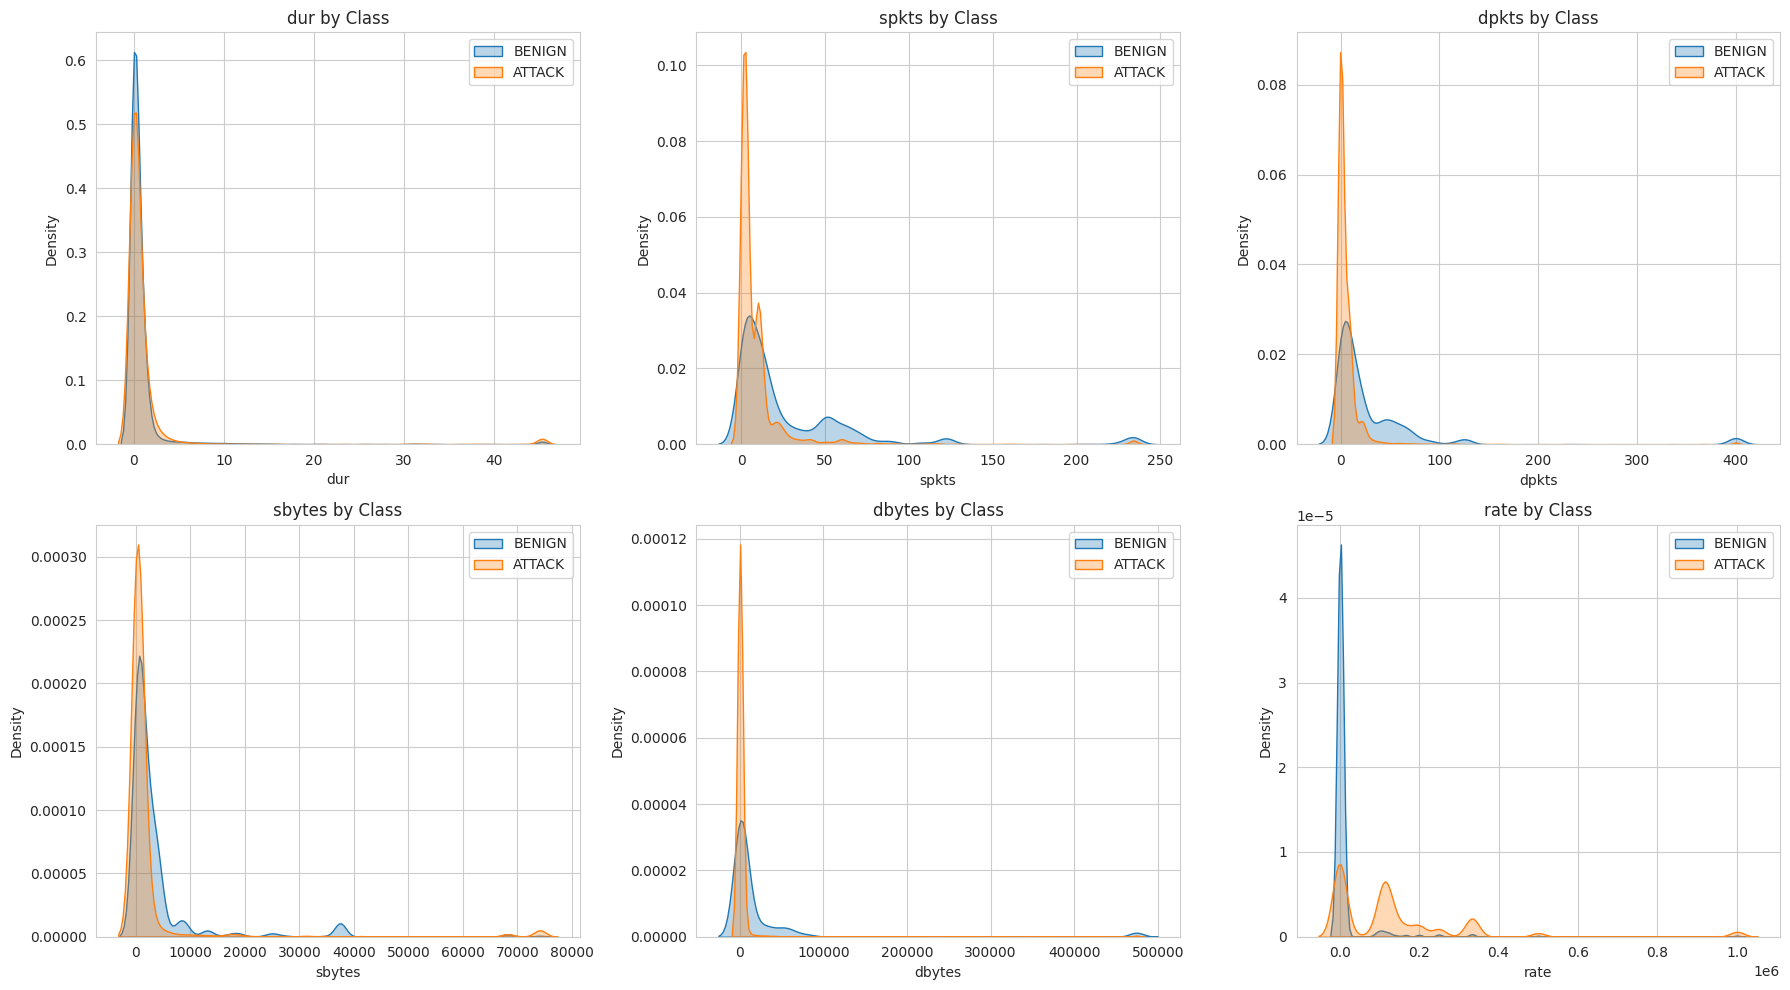

Saved: results/feature_distributions_unsw.png


In [13]:
# Distribution of key numerical features by binary class
plot_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, feat in enumerate(plot_features):
    ax = axes[idx // 3, idx % 3]

    benign = train_df[train_df['Label_binary'] == 'BENIGN'][feat]
    attack = train_df[train_df['Label_binary'] == 'ATTACK'][feat]

    # Clip extreme values only for visualization
    combined = pd.concat([benign, attack])
    upper = combined.quantile(0.99)

    sns.kdeplot(benign.clip(upper=upper), ax=ax, label='BENIGN', fill=True, alpha=0.3)
    sns.kdeplot(attack.clip(upper=upper), ax=ax, label='ATTACK', fill=True, alpha=0.3)

    ax.set_title(f'{feat} by Class')
    ax.legend()

plt.tight_layout()
plt.savefig('results/feature_distributions_unsw.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: results/feature_distributions_unsw.png')


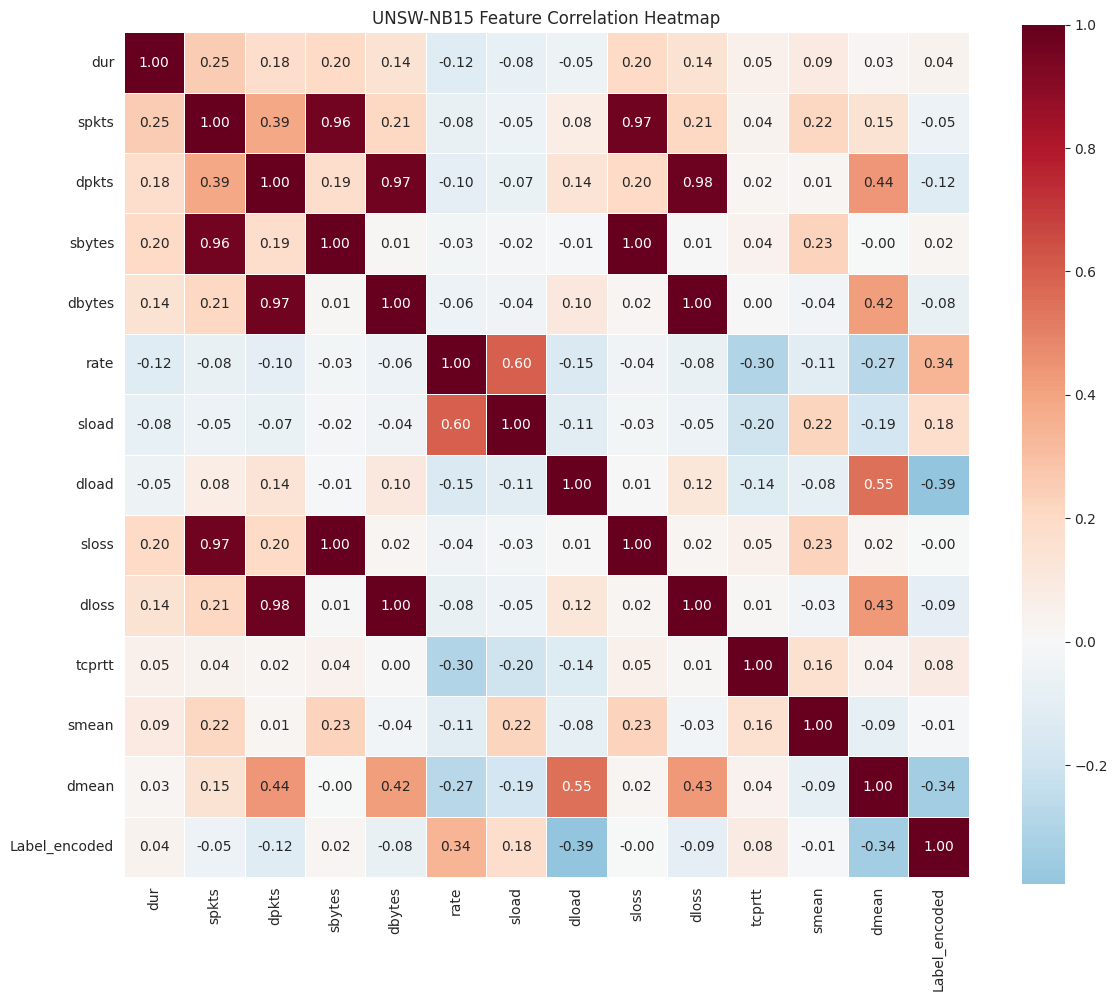

Saved: results/correlation_heatmap_unsw.png


In [14]:
# Correlation heatmap for selected UNSW-NB15 features
corr_features = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes',
    'rate', 'sload', 'dload', 'sloss', 'dloss',
    'tcprtt', 'smean', 'dmean', 'Label_encoded'
]

corr_features = [c for c in corr_features if c in train_df.columns]
corr_df = train_df[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5
)
plt.title('UNSW-NB15 Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('results/correlation_heatmap_unsw.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: results/correlation_heatmap_unsw.png')


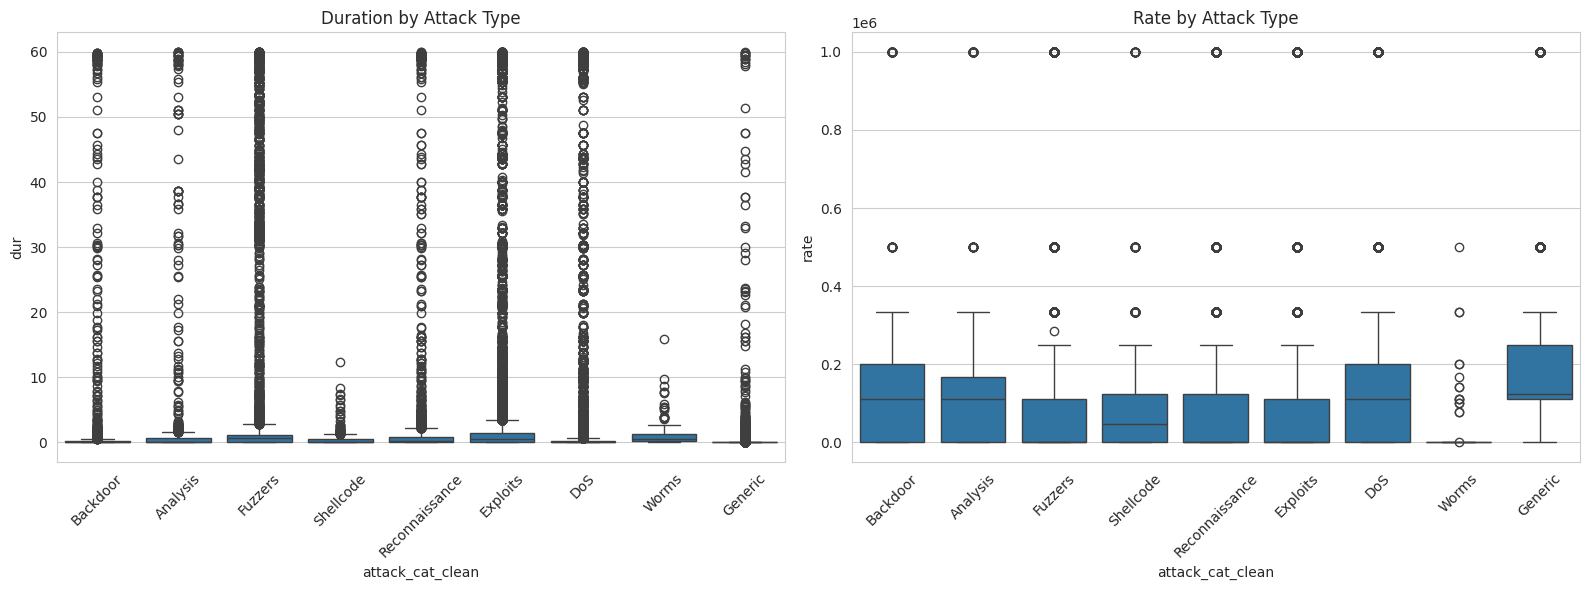

Saved: results/attack_comparison_unsw.png


In [15]:
# Compare attack categories on key features
attack_types = train_df[train_df['Label_binary'] == 'ATTACK'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=attack_types, x='attack_cat_clean', y='dur', ax=axes[0])
axes[0].set_title('Duration by Attack Type')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=attack_types, x='attack_cat_clean', y='rate', ax=axes[1])
axes[1].set_title('Rate by Attack Type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/attack_comparison_unsw.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: results/attack_comparison_unsw.png')


<Figure size 1400x600 with 0 Axes>

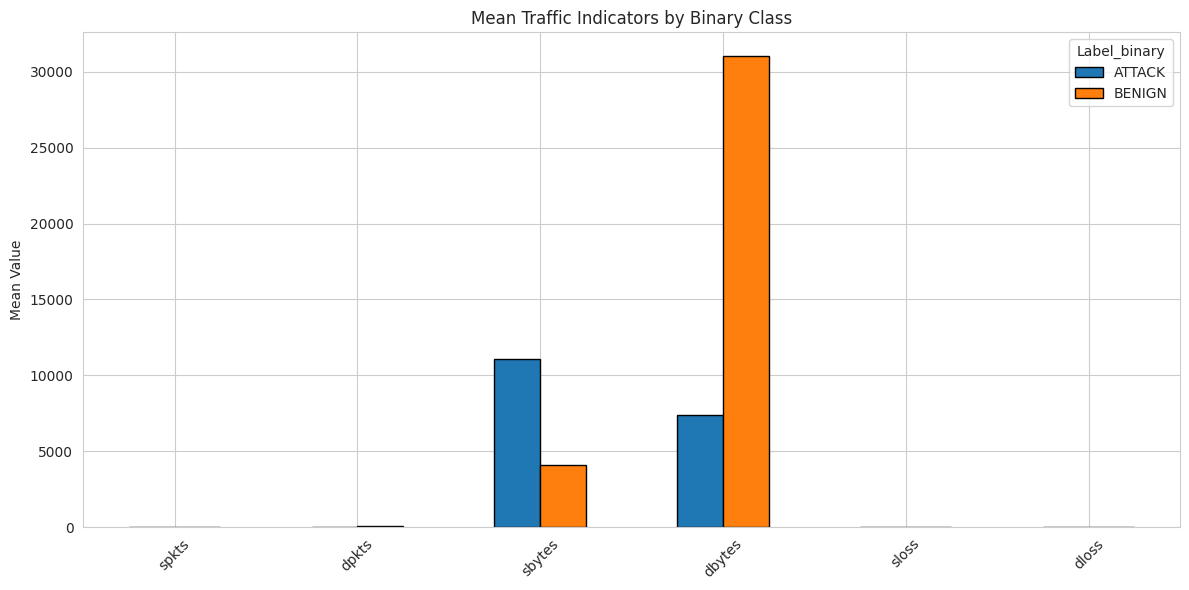

Saved: results/traffic_indicators_unsw.png


In [16]:
# Selected UNSW-NB15 traffic indicators by class
indicator_cols = ['spkts', 'dpkts', 'sbytes', 'dbytes', 'sloss', 'dloss']

class_means = train_df.groupby('Label_binary')[indicator_cols].mean()

plt.figure(figsize=(14, 6))
class_means.T.plot(kind='bar', edgecolor='black')
plt.title('Mean Traffic Indicators by Binary Class')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/traffic_indicators_unsw.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: results/traffic_indicators_unsw.png')


## 8. Feature Importance and Feature Reduction

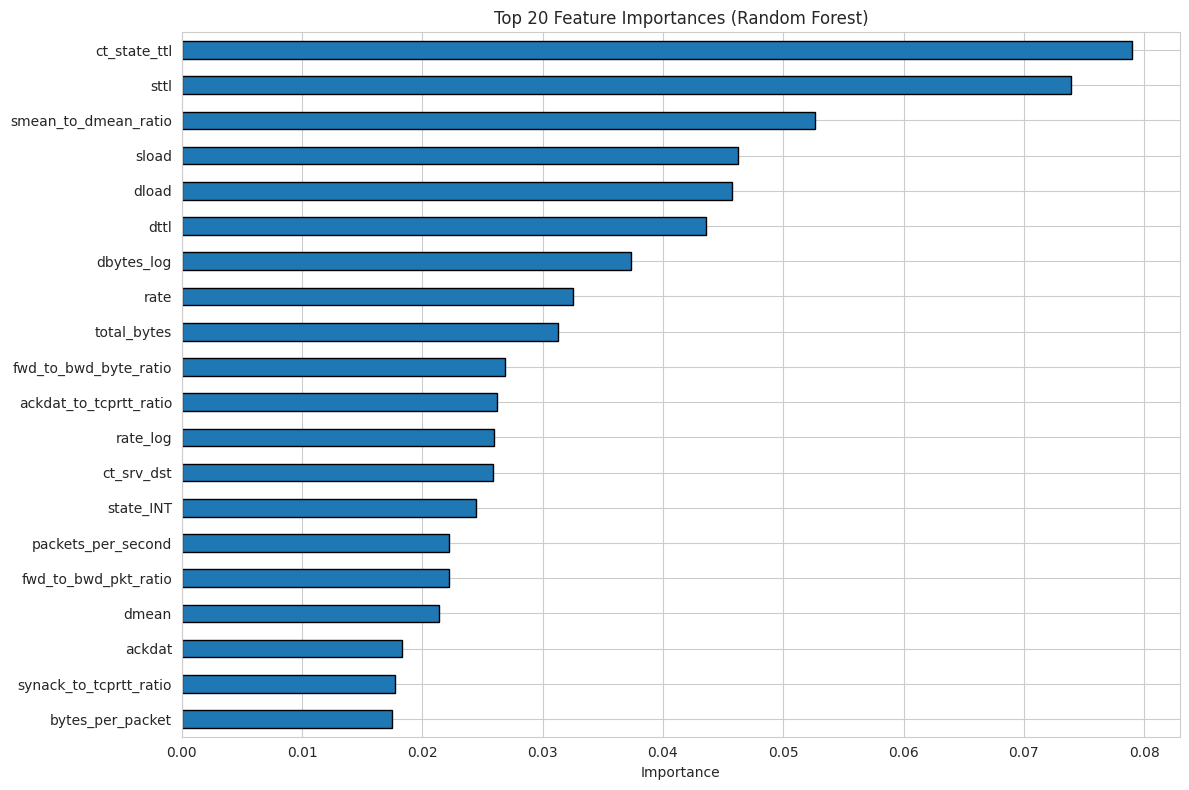

Saved: results/feature_importance_unsw.png

Top 10 important features:
ct_state_ttl             0.079030
sttl                     0.073936
smean_to_dmean_ratio     0.052663
sload                    0.046275
dload                    0.045711
dttl                     0.043572
dbytes_log               0.037370
rate                     0.032526
total_bytes              0.031282
fwd_to_bwd_byte_ratio    0.026884
dtype: float64


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Use a manageable sample for Random Forest feature selection if needed.
RF_SAMPLE_SIZE = min(100000, len(X_train_scaled))

rf_X = X_train_scaled.sample(
    n=RF_SAMPLE_SIZE,
    random_state=42
)
rf_y = y_train.loc[rf_X.index]

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(rf_X, rf_y)

importances = pd.Series(
    rf.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
importances.head(20).sort_values().plot(kind='barh', edgecolor='black')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('results/feature_importance_unsw.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: results/feature_importance_unsw.png')
print('\nTop 10 important features:')
print(importances.head(10))


In [18]:
# Select top 20 features
top_features = importances.head(20).index.tolist()

print(f'Selecting Top 20 features:')
print(top_features)

X_train_reduced = X_train_scaled[top_features].copy()
X_test_reduced = X_test_scaled[top_features].copy()

print(f'X_train reduced shape: {X_train_reduced.shape}')
print(f'X_test reduced shape: {X_test_reduced.shape}')


Selecting Top 20 features:
['ct_state_ttl', 'sttl', 'smean_to_dmean_ratio', 'sload', 'dload', 'dttl', 'dbytes_log', 'rate', 'total_bytes', 'fwd_to_bwd_byte_ratio', 'ackdat_to_tcprtt_ratio', 'rate_log', 'ct_srv_dst', 'state_INT', 'packets_per_second', 'fwd_to_bwd_pkt_ratio', 'dmean', 'ackdat', 'synack_to_tcprtt_ratio', 'bytes_per_packet']
X_train reduced shape: (175341, 20)
X_test reduced shape: (82332, 20)


## 9. Save Preprocessed Data

In [19]:
OUTPUT_DIR = 'data/preprocess'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_output = X_train_reduced.copy()
train_output['label'] = y_train.values

test_output = X_test_reduced.copy()
test_output['label'] = y_test.values

train_output.to_csv(
    f'{OUTPUT_DIR}/UNSW_NB15_train_preprocessed.csv',
    index=False
)

test_output.to_csv(
    f'{OUTPUT_DIR}/UNSW_NB15_test_preprocessed.csv',
    index=False
)

# Save feature names for later MLP/SHAP/LIME notebooks
pd.Series(top_features, name='feature').to_csv(
    f'{OUTPUT_DIR}/selected_features.csv',
    index=False
)

print(f'Train saved: {OUTPUT_DIR}/UNSW_NB15_train_preprocessed.csv')
print(f'Test saved: {OUTPUT_DIR}/UNSW_NB15_test_preprocessed.csv')
print(f'Selected features saved: {OUTPUT_DIR}/selected_features.csv')

print(f'\nFinal train shape: {train_output.shape}')
print(f'Final test shape: {test_output.shape}')
print('\nFinal binary label distribution:')
print(train_output['label'].value_counts())


Train saved: data/preprocess/UNSW_NB15_train_preprocessed.csv
Test saved: data/preprocess/UNSW_NB15_test_preprocessed.csv
Selected features saved: data/preprocess/selected_features.csv

Final train shape: (175341, 21)
Final test shape: (82332, 21)

Final binary label distribution:
label
1    119341
0     56000
Name: count, dtype: int64


## Summary

The UNSW-NB15 preprocessing pipeline:

1. Loads the official training and testing files.
2. Cleans duplicates, missing values, and infinite values.
3. Removes the identifier column.
4. Creates binary labels (BENIGN vs ATTACK).
5. Preserves attack categories for multiclass analysis.
6. Engineers traffic-related features.
7. One-hot encodes categorical network features.
8. Scales features using training data only.
9. Uses Random Forest importance to select the top 20 features.
10. Saves the processed training and testing data for the MLP, SHAP, and LIME stages.
